In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import pandas as pd

from transaction_analysis.config.paths import FRAUD_DATASET_DIR

## 3. Preprocessing danych

Optymalizacja reprezentacji tabel, dobranie właściwych typów danych.

Zawartość kolumn *na razie* nie jest zmieniana

In [6]:
cards = pd.read_csv(FRAUD_DATASET_DIR / "raw" / "cards_data.csv")
users = pd.read_csv(FRAUD_DATASET_DIR / "raw" / "users_data.csv")
cards.info()
print()
users.info()

<class 'pandas.DataFrame'>
RangeIndex: 6146 entries, 0 to 6145
Data columns (total 13 columns):
 #   Column                 Non-Null Count  Dtype
---  ------                 --------------  -----
 0   id                     6146 non-null   int64
 1   client_id              6146 non-null   int64
 2   card_brand             6146 non-null   str  
 3   card_type              6146 non-null   str  
 4   card_number            6146 non-null   int64
 5   expires                6146 non-null   str  
 6   cvv                    6146 non-null   int64
 7   has_chip               6146 non-null   str  
 8   num_cards_issued       6146 non-null   int64
 9   credit_limit           6146 non-null   str  
 10  acct_open_date         6146 non-null   str  
 11  year_pin_last_changed  6146 non-null   int64
 12  card_on_dark_web       6146 non-null   str  
dtypes: int64(6), str(7)
memory usage: 851.5 KB

<class 'pandas.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 14 columns):
 #   Colu

In [7]:
transactions = pd.read_csv(FRAUD_DATASET_DIR / "raw" / "transactions_data.csv")
transactions.info()

<class 'pandas.DataFrame'>
RangeIndex: 13305915 entries, 0 to 13305914
Data columns (total 12 columns):
 #   Column          Dtype  
---  ------          -----  
 0   id              int64  
 1   date            str    
 2   client_id       int64  
 3   card_id         int64  
 4   amount          str    
 5   use_chip        str    
 6   merchant_id     int64  
 7   merchant_city   str    
 8   merchant_state  str    
 9   zip             float64
 10  mcc             int64  
 11  errors          str    
dtypes: float64(1), int64(5), str(6)
memory usage: 1.8 GB


Aby móc komfortowo pracować z dużym zbiorem danych, należy dobrać odpowiednie typy danych dla kolumn:

- Liczby całkowitoliczbowe zostali zrzutowane na najmniejszy typ, który może je przechować
- Powtarzające się ciągi znakowe `str` zrzutowano na kategorie
- Daty zrzutowano na `datetime`
- Kolumny składające z `True`, `False` zrzutowano na `bool`

In [13]:
# del cards, users, transactions

# import transaction_analysis.data.step.preprocess as preprocess

# preprocess.run(FRAUD_DATASET_DIR / "raw", FRAUD_DATASET_DIR / "preprocessed")

cards = pd.read_parquet(FRAUD_DATASET_DIR / "preprocessed" / "cards.parquet")
users = pd.read_parquet(FRAUD_DATASET_DIR / "preprocessed" / "users.parquet")
cards.info()
print()
users.info()

<class 'pandas.DataFrame'>
RangeIndex: 6146 entries, 0 to 6145
Data columns (total 13 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   id                     6146 non-null   uint16        
 1   client_id              6146 non-null   uint16        
 2   card_brand             6146 non-null   category      
 3   card_type              6146 non-null   category      
 4   card_number            6146 non-null   int64         
 5   expires                6146 non-null   datetime64[us]
 6   cvv                    6146 non-null   uint16        
 7   has_chip               6146 non-null   boolean       
 8   num_cards_issued       6146 non-null   uint8         
 9   credit_limit           6146 non-null   float32       
 10  acct_open_date         6146 non-null   datetime64[us]
 11  year_pin_last_changed  6146 non-null   uint16        
 12  card_on_dark_web       6146 non-null   boolean       
dtypes: boolean(2),

In [11]:
transactions = pd.read_parquet(FRAUD_DATASET_DIR / "preprocessed" / "transactions.parquet")
transactions.info()

<class 'pandas.DataFrame'>
RangeIndex: 13305915 entries, 0 to 13305914
Data columns (total 12 columns):
 #   Column          Dtype         
---  ------          -----         
 0   id              uint32        
 1   date            datetime64[us]
 2   client_id       uint16        
 3   card_id         uint16        
 4   amount          float32       
 5   use_chip        category      
 6   merchant_id     uint32        
 7   merchant_city   category      
 8   merchant_state  category      
 9   zip             category      
 10  mcc             uint16        
 11  errors          category      
dtypes: category(5), datetime64[us](1), float32(1), uint16(3), uint32(2)
memory usage: 432.0 MB


Początkowa wersja `transactions` zużywa 1800 MB RAM; zoptymalizowana - 432 MB RAM: 75% mniej

Na dysku `transactions.csv` zajmuje 1200 MB, zoptymalizowany `transactions.paquet` - 259 MB: 78% mniej

Wiedząc optymalne typy danych dla każdej z kolumn w tabeli (schema), możemy następnym razem otworzyć **od razu optymalną wersję** `.csv` **wraz z powyższych schematem**

`.parquet` pamięta o typach danych dla kolumn i nie potrzebuje schematu

Zużycie RAM można jeszcze bardziej zmniejszyć, wykorzystując silnik `pyarrow` zamiast domyślnego `numpy`

PyArrow oferuje optymalne przechowanie danych w pamięci oraz wsparcie wartości finansowych `Decimal`
Niestety, typ `Decimal` nie wspiera agregacji `mean()`, `std()`.

Z uwagi na potencjalne problemy z kompatybilinością `pyarrow` <-> `numpy`, stosowanego w `pandas` i `scikit-learn`, zrezygnowano z PyArrow na rzecz NumPy

## 4. Czyszczenie danych

Na tym etapie są zmieniane nazwy dla kolumn. Niektóre z nich są usuwane. Dane są dopasowywane dla wygody dalszej analizy

In [ ]:
import transaction_analysis.data.step.cleanup as cleanup

cleanup.run(FRAUD_DATASET_DIR / "preprocessed", FRAUD_DATASET_DIR / "cleaned", force=True)

Funkcja `assert_no_missing_values` sprawdza, czy kolumna nie zawiera brakujących wartości

Mamy pewność, że wskazane kolumny są "bezpieczne"

## 5. EDA - profilowanie transakcji oszukańczych

In [14]:
from transaction_analysis.config.paths import PLOTS_DIR
from transaction_analysis.data.loader import load_all_transactions, load_mcc_codes
from transaction_analysis.eda.pca import build_client_fraud_profile
from transaction_analysis.eda.step.analysis import TransactionAnalysis
from transaction_analysis.eda.visualizations import (
    plot_fraud_frequent_age,
    plot_fraudster_channel_mix,
    plot_fraudster_profile,
    plot_mcc_fraud_rate,
    plot_merchant_fraud_rate,
    plot_merchant_fraud_rate_volume,
    plot_state_fraud_rate,
    plot_top_states_by_amount,
)

analysis = TransactionAnalysis(load_all_transactions(), output_dir=PLOTS_DIR)

Na początku wygląda, że w transakcjach `Online` może być najwięcej oszustw...

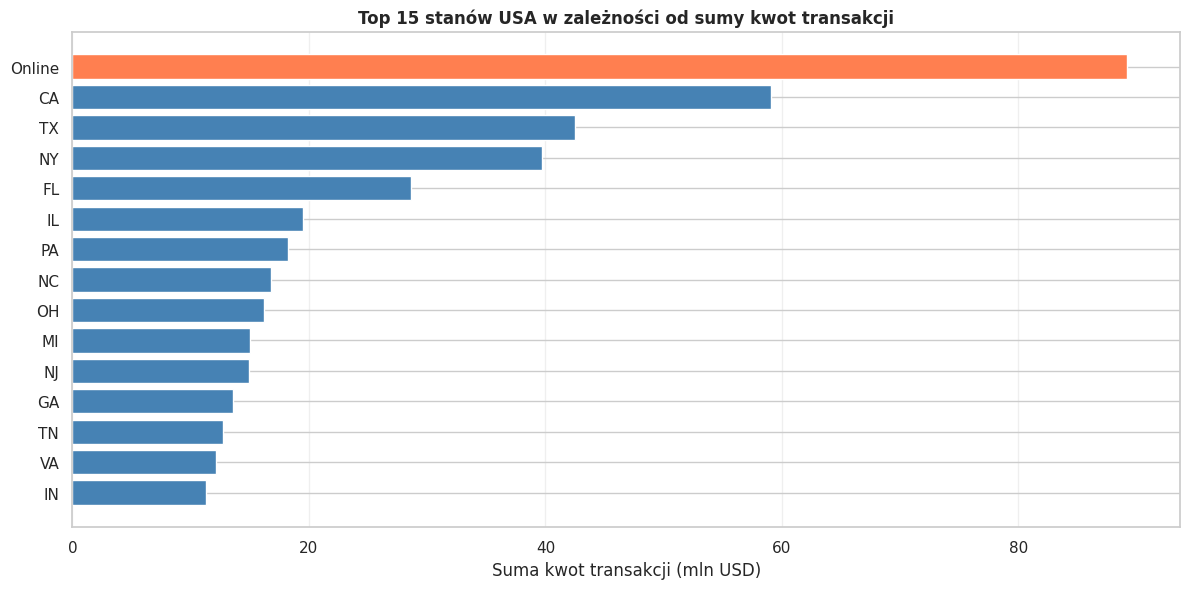

In [15]:
analysis.plot_graph(plot_top_states_by_amount, analysis.transactions, top_n=15)

Ale procent transakcji oszukańczych względem każdego ze stanów mówi zupełnie inaczej!

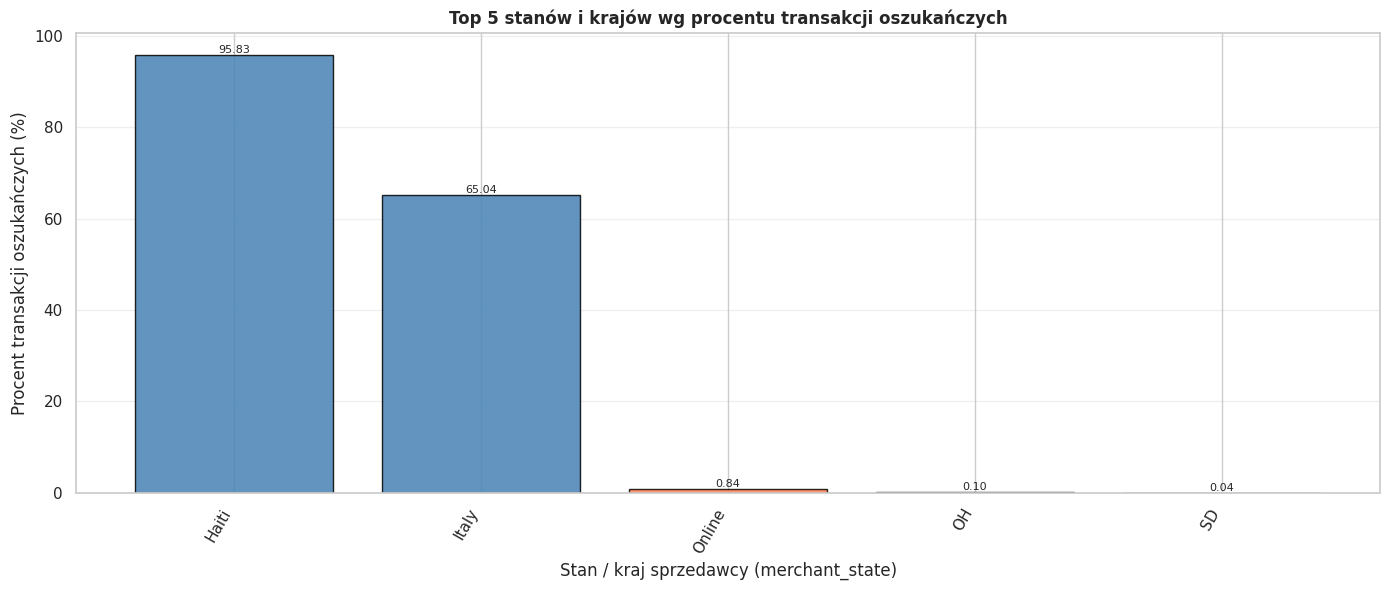

In [16]:
analysis.plot_graph(
    plot_state_fraud_rate,
    load_all_transactions(),
    top_n=5,
    min_transactions=100,
)

Tak samo z poszukiwaniem branż, gdzie najczęściej odbywają się oszustwa: sklepy nie są dobrym wyznacznikiem

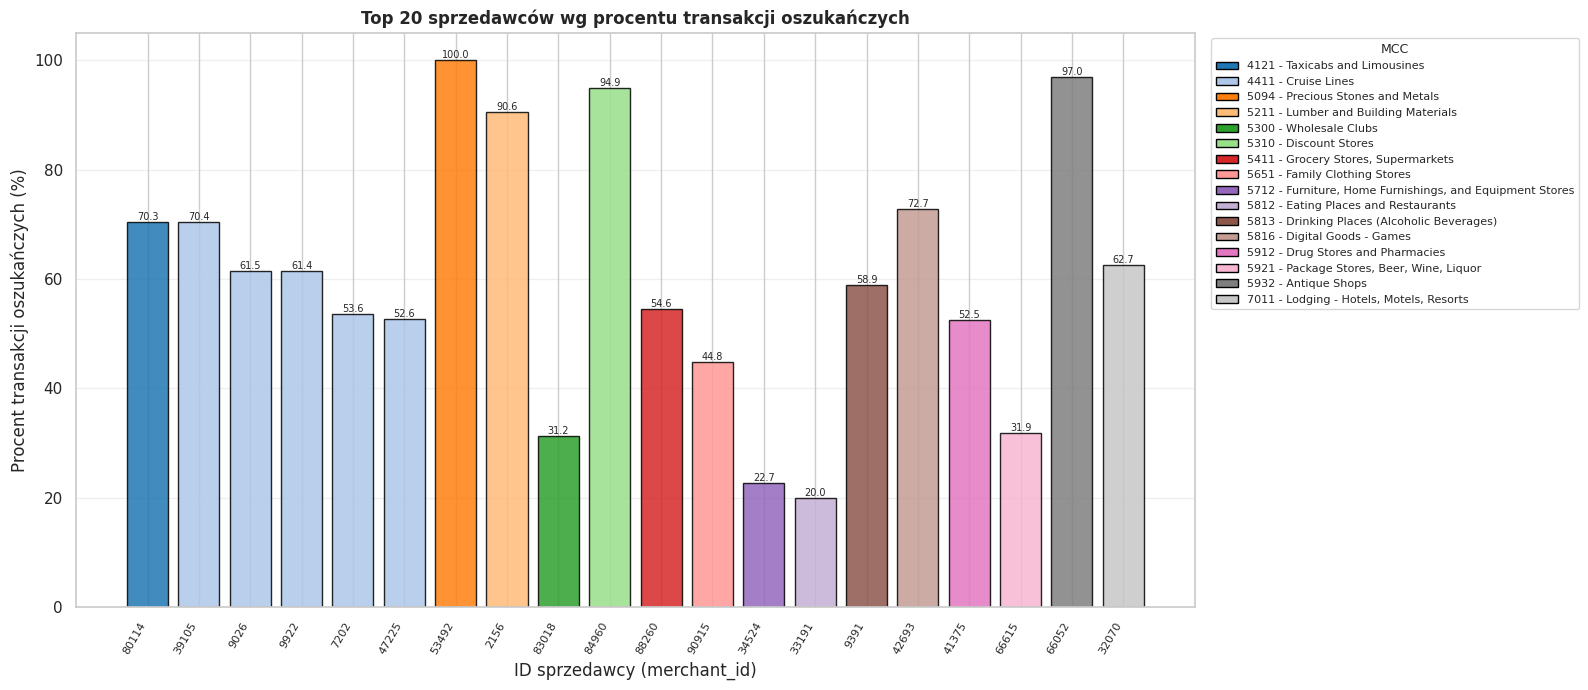

In [17]:
analysis.plot_graph(
    plot_merchant_fraud_rate,
    load_all_transactions(),
    mcc_codes=load_mcc_codes(),
    top_n=20,
    min_transactions=50,
)

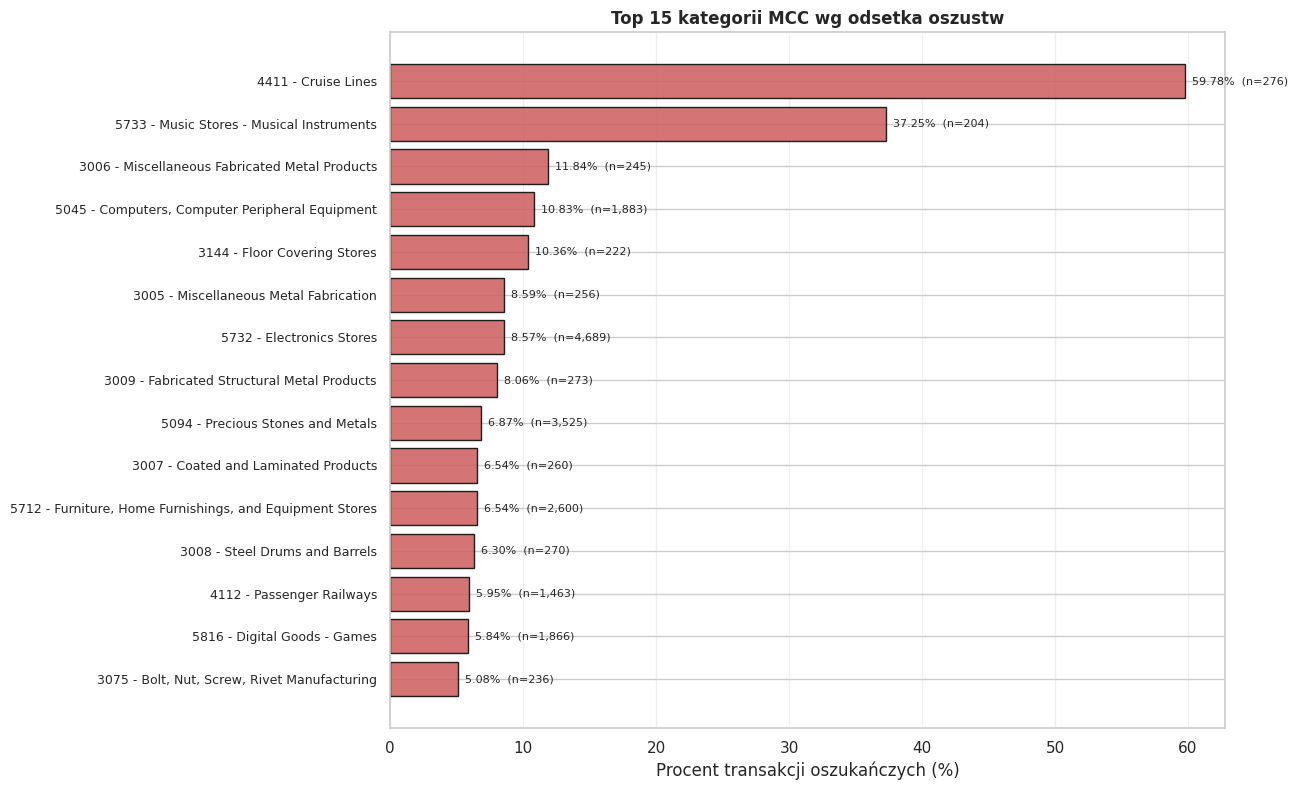

In [18]:
analysis.plot_graph(
    plot_mcc_fraud_rate,
    load_all_transactions(),
    mcc_codes=load_mcc_codes(),
    top_n=15,
    min_transactions=50,
)

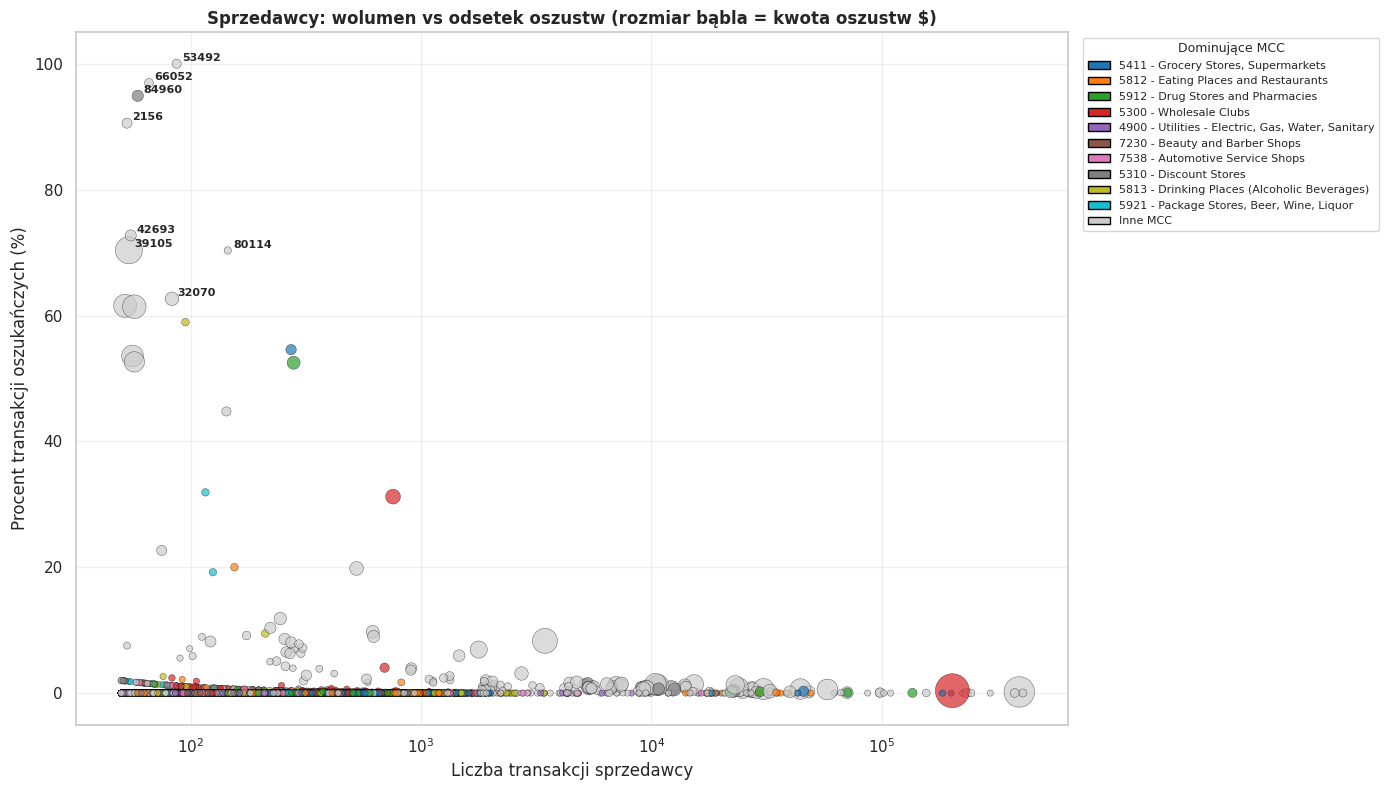

In [19]:
analysis.plot_graph(
    plot_merchant_fraud_rate_volume,
    load_all_transactions(),
    mcc_codes=load_mcc_codes(),
    min_transactions=50,
)

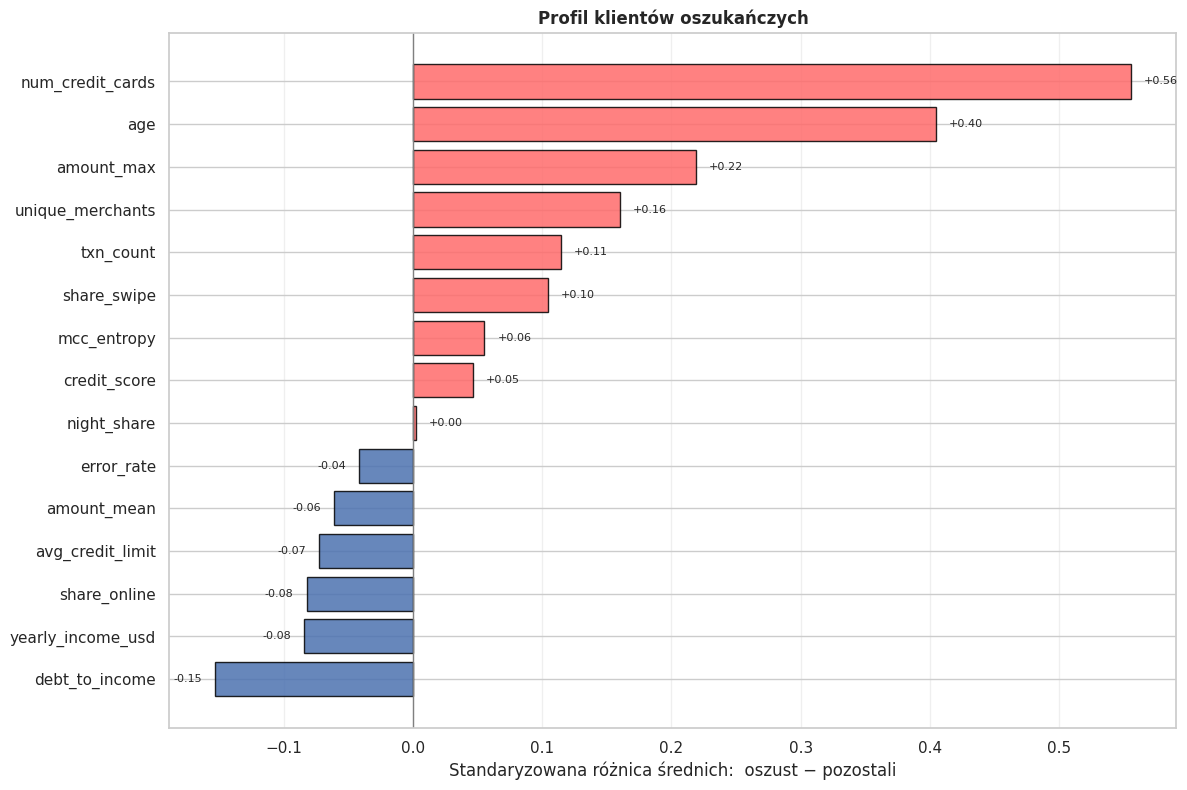

In [ ]:
profile = build_client_fraud_profile(analysis.transactions, analysis.users, analysis.cards, min_fraud_txns=10)
analysis.plot_graph(plot_fraudster_profile, profile)

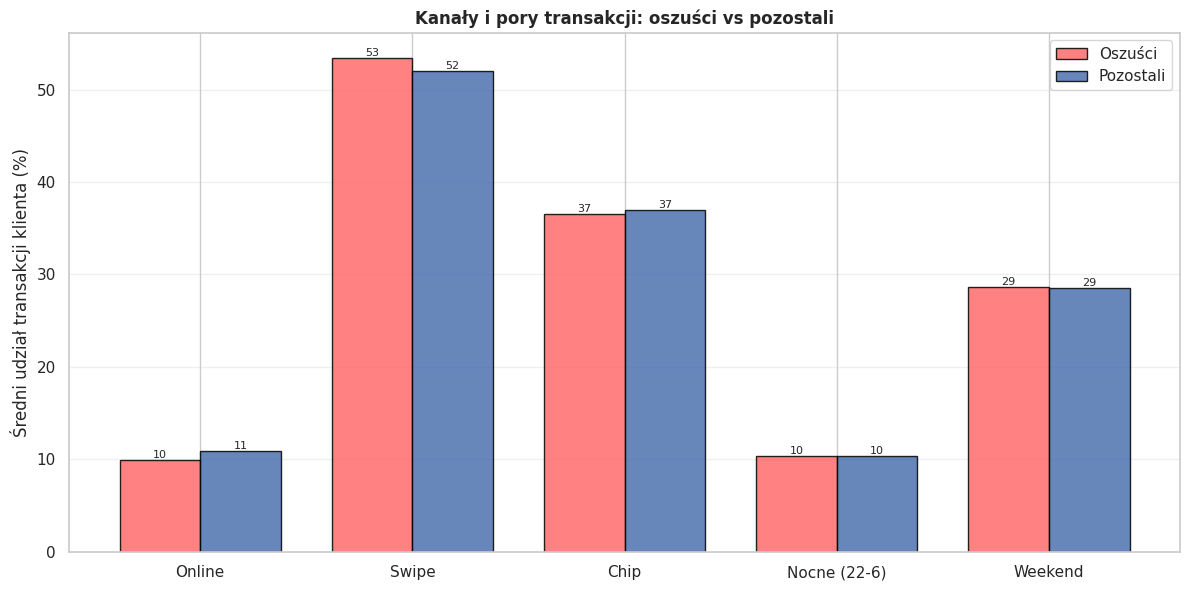

In [21]:
analysis.plot_graph(plot_fraudster_channel_mix, profile)

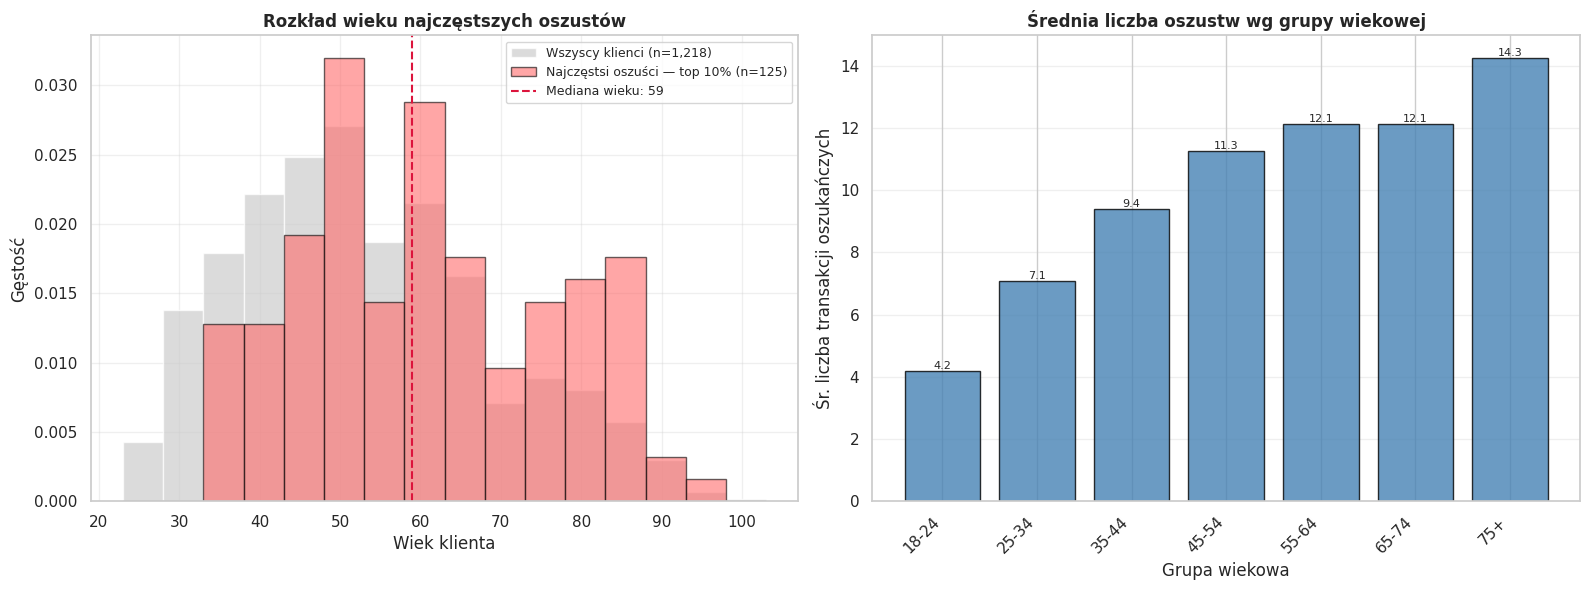

In [22]:
analysis.plot_graph(plot_fraud_frequent_age, profile, top_frac=0.1)